In [1]:
import pandas as pd

df_base_ood = pd.read_json('../../data/test/benchmark_zs_real.jsonl', lines=True, orient='records')
df_base_id = pd.read_json('../../data/test/benchmark_zs_synt_test.jsonl',lines=True, orient='records')

In [7]:
df_base_ood.groupby(['model', 'quant'])[[ 'codebleu', 'codebert_f1', 'bleu', 'meteor', 'rouge1','rouge2', 'rougeL']].mean()

,,codebleu,codebert_f1,bleu,meteor,rouge1,rouge2,rougeL
model,quant,,,,,,,
codegemma_7b_it_q4_k_m,Q4_K_M,0.180913,0.677824,0.004560,0.090529,0.157974,0.040201,0.120092
codegemma_7b_it_q8_0,Q8_0,0.186558,0.675509,0.004026,0.099333,0.148690,0.035168,0.107726
codellama_7b_instruct_q4_k_m,Q4_K_M,0.193673,0.721934,0.008883,0.097231,0.220367,0.094619,0.179389
codellama_7b_instruct_q8_0,Q8_0,0.211857,0.725798,0.010334,0.106639,0.234108,0.100627,0.194418
deepseek_coder_6_7b_q4_k_m,Q4_K_M,0.257682,0.750122,0.020432,0.179587,0.300117,0.142885,0.239407
deepseek_coder_6_7b_q8_0,Q8_0,0.263551,0.745993,0.018938,0.185269,0.291410,0.132158,0.227696
mamba_codestral_7b_q4_0,Q4_0,0.219645,0.751139,0.010446,0.086751,0.280283,0.140466,0.236267
mamba_codestral_7b_q8_0,Q8_0,0.214416,0.748367,0.010185,0.083161,0.280477,0.142906,0.241479
qwen2_5_coder_7b_q4_k_m,Q4_K_M,0.241272,0.792230,0.023571,0.149229,0.375515,0.205851,0.312359


In [35]:
df_con=pd.concat([df_base_ood,df_base_id],axis=0)

In [8]:
df_base_id.groupby(['model', 'variant', 'quant'])[[ 'codebleu', 'codebert_f1', 'bleu', 'meteor', 'rouge1',
       'rouge2', 'rougeL']].mean()


,,,codebleu,codebert_f1,bleu,meteor,rouge1,rouge2,rougeL
model,variant,quant,,,,,,,
codegemma_7b_it_q4_k_m,base,Q4_K_M,0.235989,0.713903,0.004539,0.078218,0.181992,0.065998,0.146422
codegemma_7b_it_q8_0,base,Q8_0,0.233372,0.701614,0.004495,0.084519,0.164364,0.053533,0.128204
codellama_7b_instruct_q4_k_m,base,Q4_K_M,0.242240,0.773489,0.013428,0.103780,0.325568,0.201022,0.271273
codellama_7b_instruct_q8_0,base,Q8_0,0.268686,0.784311,0.017573,0.123251,0.352369,0.216915,0.286852
deepseek_coder_6_7b_q4_k_m,base,Q4_K_M,0.329785,0.799057,0.027030,0.215487,0.391653,0.265536,0.303842
deepseek_coder_6_7b_q8_0,base,Q8_0,0.329020,0.794479,0.024074,0.212582,0.362033,0.236599,0.281114
mamba_codestral_7b_q4_0,base,Q4_0,0.313160,0.815528,0.017863,0.097037,0.415992,0.291551,0.367098
mamba_codestral_7b_q8_0,base,Q8_0,0.309555,0.818551,0.020853,0.093121,0.431407,0.314171,0.381478
qwen2_5_coder_7b_q4_k_m,base,Q4_K_M,0.389568,0.894670,0.084286,0.328099,0.640564,0.515178,0.554499


In [39]:
import pandas as pd

# Colonne di metriche che usi nei tuoi groupby
METRICS = [
    "codebleu",
    "codebert_f1",
    "bleu",
    "meteor",
    "rouge1",
    "rouge2",
    "rougeL",
]


def aggregate_by_model_variant_quant(df: pd.DataFrame) -> pd.DataFrame:
    """
    Raggruppa per (model, variant, quant) e calcola la media delle metriche.
    Restituisce un DataFrame con queste colonne come indici.
    """
    grouped = (
        df.groupby(["model", "variant", "quant"])[METRICS]
        .mean()
        .sort_index()
    )
    return grouped


def build_comparison_table(df_id: pd.DataFrame, df_ood: pd.DataFrame) -> pd.DataFrame:
    """
    Costruisce una tabella di confronto tra ID e OOD:
    - colonne *_id: medie sulle istanze in-distribution
    - colonne *_ood: medie sulle istanze out-of-distribution
    - colonne *_diff: differenza assoluta (ID - OOD)
    - colonne *_rel_drop_%: drop percentuale rispetto a ID
    """
    id_agg = aggregate_by_model_variant_quant(df_id).add_suffix("_id")
    ood_agg = aggregate_by_model_variant_quant(df_ood).add_suffix("_ood")

    # Join sugli indici (model, variant, quant)
    comparison = id_agg.join(ood_agg, how="inner")

    # Calcolo differenze e drop percentuali
    for m in METRICS:
        col_id = f"{m}_id"
        col_ood = f"{m}_ood"
        diff_col = f"{m}_diff"
        drop_col = f"{m}_rel_drop_%"

        comparison[diff_col] = comparison[col_id] - comparison[col_ood]

        # Per evitare divisioni per zero:
        comparison[drop_col] = (
            (comparison[col_id] - comparison[col_ood]) / comparison[col_id]
        ) * 100
        # Dove codebleu_id = 0 -> NaN
        comparison.loc[comparison[col_id] == 0, drop_col] = float("nan")

    return comparison


def summarize_by_model(comparison: pd.DataFrame) -> pd.DataFrame:
    """
    Riassume, per ogni modello, il drop percentuale medio sulle metriche.
    Usa le colonne *_rel_drop_% della tabella di confronto.
    """
    df_reset = comparison.reset_index()

    # Prendiamo solo le colonne di drop percentuale
    drop_cols = [c for c in df_reset.columns if c.endswith("_rel_drop_%")]

    model_summary = (
        df_reset.groupby("model")[drop_cols]
        .mean()
        .sort_values(by="codebleu_rel_drop_%", ascending=True)
    )

    return model_summary


comparison = build_comparison_table(df_con, df_base_id)
model_summary = summarize_by_model(comparison)




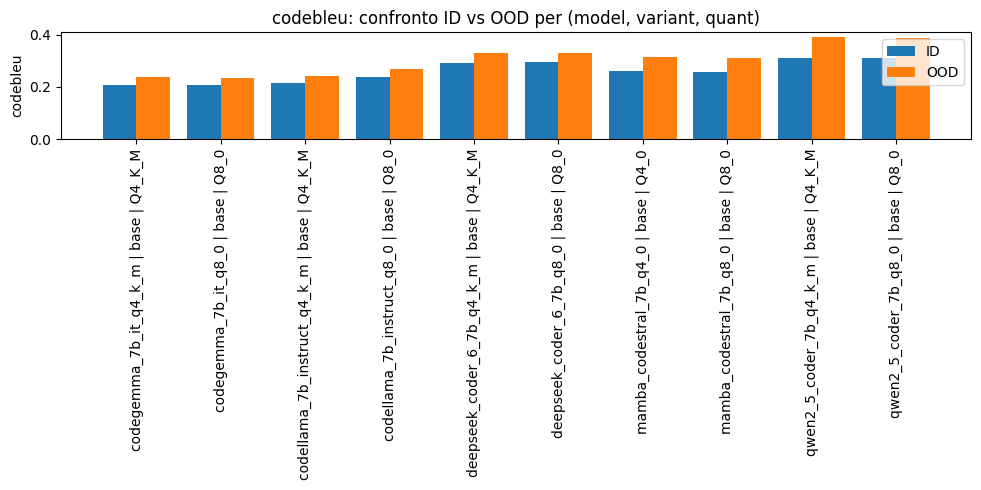

In [40]:
def plot_id_ood_by_model_variant_quant(comparison: pd.DataFrame, metric: str):
    """
    Disegna un grafico a barre per una metrica specifica:
    - ID e OOD affiancati
    - per ogni (model, variant, quant)
    """
    col_id = f"{metric}_id"
    col_ood = f"{metric}_ood"

    if col_id not in comparison.columns or col_ood not in comparison.columns:
        raise ValueError(f"Metrica {metric} non trovata in comparison")

    # Reset index per avere le colonne esplicite
    df_plot = comparison.reset_index()[["model", "variant", "quant", col_id, col_ood]]

    # Creiamo una label comoda per l'asse X
    df_plot["label"] = (
        df_plot["model"] + " | " + df_plot["variant"] + " | " + df_plot["quant"].astype(str)
    )

    x = range(len(df_plot))
    width = 0.4

    plt.figure(figsize=(10, 5))
    plt.bar([i - width/2 for i in x], df_plot[col_id], width=width, label="ID")
    plt.bar([i + width/2 for i in x], df_plot[col_ood], width=width, label="OOD")

    plt.xticks(list(x), df_plot["label"], rotation=90)
    plt.ylabel(metric)
    plt.title(f"{metric}: confronto ID vs OOD per (model, variant, quant)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Esempio:
plot_id_ood_by_model_variant_quant(comparison, "codebleu")
